# USRegistrator pipeline tutorial

This notebook walks through the full synthetic-data registration pipeline in this repository. The key constraint is that the actual training and validation run should still go through the real command-line entrypoint, not a reimplementation inside the notebook.

The recommended workflow in this repo is:

1. Edit `configs/deepreg_synth.yaml`.
2. Run `python main.py`.

For the tutorial only, we will also use a tiny override config so the full pipeline can finish quickly. That override uses `python main.py --config ...`, but that is a convenience for the notebook rather than the main intended workflow.

## What this notebook covers

- Where the pipeline starts
- How the YAML configs drive dataset, model, loss, optimizer, and training settings
- What the built-in synthetic dataset produces
- How to run a tiny end-to-end experiment with the real CLI
- How to switch back to the normal workflow of editing the main config file and running `python main.py`

In [1]:
from pathlib import Path
import yaml

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

## Environment setup

Before running the training command, make sure your environment has the project dependencies installed. A typical setup is:

```bash
python -m venv venv
source venv/bin/activate
pip install -r requirements.txt
pip install torch torchvision torchaudio
```

After that, the command used throughout the tutorial is simply `python main.py`.

## Pipeline map

The main files involved in the tutorial are:

- `main.py`: user-facing entrypoint
- `train.py`: training loop implementation
- `datasets/`: synthetic dataset factories (package with a registry)
- `models/`: registration models (package with a registry)
- `losses/`: loss builders and implementations
- `metrics/`: validation metrics
- `configs/deepreg_synth.yaml`: recommended default config to edit
- `configs/deepreg_synth_tutorial.yaml`: tiny tutorial config for a fast demo

In normal use, `python main.py` loads `configs/deepreg_synth.yaml` by default.

In [2]:
important_paths = [
    'main.py',
    'train.py',
    'datasets',
    'models',
    'losses',
    'metrics',
    'configs/deepreg_synth.yaml',
    'configs/deepreg_synth_tutorial.yaml',
]
for rel_path in important_paths:
    path = repo_root / rel_path
    print(f'{rel_path}:', 'found' if path.exists() else 'missing')

main.py: found
train.py: found
datasets: found
models: found
losses: found
metrics: found
configs/deepreg_synth.yaml: found
configs/deepreg_synth_tutorial.yaml: found


## The normal workflow

Most of the time, you should not need to pass `--config`. Instead:

1. Open `configs/deepreg_synth.yaml`.
2. Change the values you want.
3. Run `python main.py`.

That keeps the run command stable and makes the config file itself the source of truth for the experiment.

In [3]:
default_cfg_path = repo_root / 'configs' / 'deepreg_synth.yaml'
tutorial_cfg_path = repo_root / 'configs' / 'deepreg_synth_tutorial.yaml'

with default_cfg_path.open() as f:
    default_cfg = yaml.safe_load(f)

with tutorial_cfg_path.open() as f:
    tutorial_cfg = yaml.safe_load(f)

default_cfg

{'project': 'monai-3d-registration',
 'image_size': [64, 64, 64],
 'train_dataset': {'name': 'deepreg_synthetic',
  'image_size': [64, 64, 64],
  'num_samples': 4000,
  'max_disp': 0.2,
  'cp_spacing': 8,
  'noise_std': 0.03,
  'smooth': True,
  'seed': 123},
 'val_dataset': {'name': 'deepreg_synthetic',
  'image_size': [64, 64, 64],
  'num_samples': 200,
  'max_disp': 0.2,
  'cp_spacing': 8,
  'noise_std': 0.03,
  'smooth': True,
  'seed': 456},
 'model': {'name': 'globalnet3d',
  'num_channel_initial': 16,
  'depth': 3,
  'warp_mode': 'bilinear',
  'warp_padding_mode': 'border'},
 'loss': {'name': 'lncc_dvf',
  'kernel_size': 9,
  'smooth_nr': '1e-4',
  'smooth_dr': '1e-2',
  'image_weight': 1.0,
  'dvf_weight': 0.1},
 'optimizer': {'name': 'Adam', 'lr': '1e-4', 'weight_decay': '1e-5'},
 'training': {'epochs': 50,
  'batch_size': 2,
  'num_workers': 4,
  'amp': True,
  'val_every': 1,
  'seed': 42},
 'wandb': {'enabled': True,
  'project': 'usregistrator',
  'run_name': 'deepreg_synt

## Config sections

The default synthetic config is organized into a few sections. Each section maps directly to code used by `train.py`.

- `train_dataset`: controls how training samples are generated
- `val_dataset`: controls validation sample generation
- `model`: selects the registration network and its parameters
- `loss`: selects the optimization objective
- `optimizer`: selects the optimizer and learning rate settings
- `training`: controls epochs, batch size, workers, AMP, and validation frequency
- `wandb`: controls experiment logging

In [4]:
for section in ['train_dataset', 'val_dataset', 'model', 'loss', 'optimizer', 'training', 'wandb']:
    print(f'## {section}')
    print(yaml.safe_dump(default_cfg[section], sort_keys=False))

## train_dataset
name: deepreg_synthetic
image_size:
- 64
- 64
- 64
num_samples: 4000
max_disp: 0.2
cp_spacing: 8
noise_std: 0.03
smooth: true
seed: 123

## val_dataset
name: deepreg_synthetic
image_size:
- 64
- 64
- 64
num_samples: 200
max_disp: 0.2
cp_spacing: 8
noise_std: 0.03
smooth: true
seed: 456

## model
name: globalnet3d
num_channel_initial: 16
depth: 3
warp_mode: bilinear
warp_padding_mode: border

## loss
name: lncc_dvf
kernel_size: 9
smooth_nr: 1e-4
smooth_dr: 1e-2
image_weight: 1.0
dvf_weight: 0.1

## optimizer
name: Adam
lr: 1e-4
weight_decay: 1e-5

## training
epochs: 50
batch_size: 2
num_workers: 4
amp: true
val_every: 1
seed: 42

## wandb
enabled: true
project: usregistrator
run_name: deepreg_synth
offline: true



## What the main synthetic config is doing

`configs/deepreg_synth.yaml` uses the built-in `deepreg_synthetic` dataset. That dataset generates a synthetic fixed image, creates a smooth displacement field, warps the fixed image to create a moving image, and returns the ground-truth DVF as supervision.

That is why this config pairs naturally with the `lncc_dvf` loss:

- `lncc` compares the warped image to the fixed image
- `dvf_weight` adds direct supervision against the synthetic ground-truth DVF

In [5]:
import sys
sys.path.insert(0, str(repo_root))

from datasets import build_dataset

sample_ds = build_dataset(tutorial_cfg['train_dataset'], split='train')
sample = sample_ds[0]
{key: tuple(value.shape) for key, value in sample.items()}

{'moving': (1, 32, 32, 32), 'fixed': (1, 32, 32, 32), 'dvf': (3, 32, 32, 32)}

In [6]:
for key, value in sample.items():
    print(
        key,
        'shape=', tuple(value.shape),
        'dtype=', value.dtype,
        'min=', float(value.min()),
        'max=', float(value.max()),
    )

moving shape= (1, 32, 32, 32) dtype= torch.float32 min= 0.0 max= 1.0000001192092896
fixed shape= (1, 32, 32, 32) dtype= torch.float32 min= 0.0 max= 1.0
dvf shape= (3, 32, 32, 32) dtype= torch.float32 min= -0.36638832092285156 max= 0.2916298806667328


## Optional quick slice visualization

This cell is optional. It only runs if `matplotlib` is available in your environment.

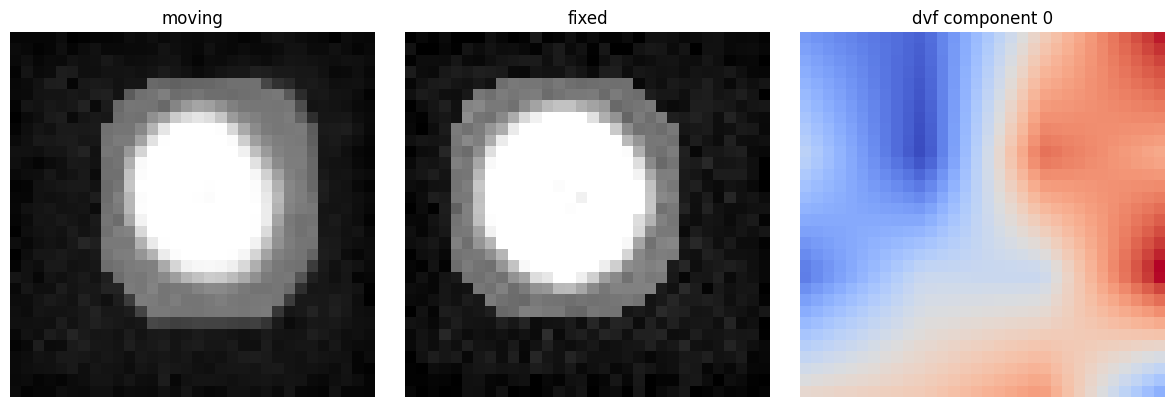

In [7]:
import matplotlib.pyplot as plt

mid = sample['moving'].shape[1] // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample['moving'][0, mid].numpy(), cmap='gray')
axes[0].set_title('moving')
axes[1].imshow(sample['fixed'][0, mid].numpy(), cmap='gray')
axes[1].set_title('fixed')
axes[2].imshow(sample['dvf'][0, mid].numpy(), cmap='coolwarm')
axes[2].set_title('dvf component 0')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## Why there is a separate tutorial config

The default config is sized for a more realistic run. For a notebook tutorial, that is unnecessary. The tutorial config keeps the same pipeline but reduces the workload so the command finishes quickly.

Here is the small version we will use for the demo run.

In [8]:
tutorial_cfg

{'project': 'monai-3d-registration',
 'image_size': [32, 32, 32],
 'train_dataset': {'name': 'deepreg_synthetic',
  'image_size': [32, 32, 32],
  'num_samples': 8,
  'max_disp': 0.2,
  'cp_spacing': 8,
  'noise_std': 0.03,
  'smooth': True,
  'seed': 123},
 'val_dataset': {'name': 'deepreg_synthetic',
  'image_size': [32, 32, 32],
  'num_samples': 2,
  'max_disp': 0.2,
  'cp_spacing': 8,
  'noise_std': 0.03,
  'smooth': True,
  'seed': 456},
 'model': {'name': 'globalnet3d',
  'num_channel_initial': 8,
  'depth': 3,
  'warp_mode': 'bilinear',
  'warp_padding_mode': 'border'},
 'loss': {'name': 'lncc_dvf',
  'kernel_size': 5,
  'smooth_nr': '1e-4',
  'smooth_dr': '1e-2',
  'image_weight': 1.0,
  'dvf_weight': 0.1},
 'optimizer': {'name': 'Adam', 'lr': '1e-4', 'weight_decay': '1e-5'},
 'training': {'epochs': 2,
  'batch_size': 1,
  'num_workers': 0,
  'amp': False,
  'val_every': 1,
  'seed': 42},
 'wandb': {'enabled': True,
  'project': 'usregistrator',
  'run_name': 'deepreg_synth_tuto

## Tutorial run: execute the real pipeline

This is the main point of the notebook: we still launch the actual pipeline through the CLI.

For the tutorial only, we use `--config` to point at the tiny demo config. In everyday use, you would usually edit `configs/deepreg_synth.yaml` and run `python main.py` without any override.

In [9]:
import subprocess

command = ['python', 'main.py', '--config', 'configs/deepreg_synth_tutorial.yaml']
print('Running:', ' '.join(command))
subprocess.run(command, cwd=repo_root, check=True)

Running: python main.py --config configs/deepreg_synth_tutorial.yaml


wandb: Tracking run with wandb version 0.26.0
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /home/aniketh/Projects/USRegistrator/wandb/offline-run-20260417_203215-ukc31r2e
/home/aniketh/Projects/USRegistrator/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


---- Dataset sanity check ----
moving: 0.0 1.0000001192092896
fixed: 0.0 1.0
any NaN: False False
any Inf: False False
--------------------------------
Device: cpu
AMP: False
Train samples: 8, Val samples: 2


/home/aniketh/Projects/USRegistrator/venv/lib/python3.10/site-packages/monai/networks/blocks/warp.py:72: UserWarning: monai.networks.blocks.Warp: Using PyTorch native grid_sample.
  warnings.warn("monai.networks.blocks.Warp: Using PyTorch native grid_sample.")


[Epoch 001/002] train_loss = -0.3079, val_loss = -0.2709, val_ncc = 0.6075, val_epe = 0.2454, val_grad_l2 = 0.0000
[Epoch 002/002] train_loss = -0.3257, val_loss = -0.3430, val_ncc = 0.7966, val_epe = 0.3712, val_grad_l2 = 0.0000


wandb: 
wandb: Run history:
wandb:       epoch ▁▁██
wandb:  train/loss █▁
wandb:     val/epe ▁█
wandb: val/grad_l2 █▁
wandb:    val/loss █▁
wandb:     val/mae █▁
wandb:     val/mse █▁
wandb:     val/ncc ▁█
wandb: 
wandb: Run summary:
wandb:       epoch 2
wandb:  train/loss -0.32566
wandb:     val/epe 0.37117
wandb: val/grad_l2 0.0
wandb:    val/loss -0.34297
wandb:     val/mae 0.081
wandb:     val/mse 0.02433
wandb:     val/ncc 0.79662
wandb: 
wandb: You can sync this run to the cloud by running:
wandb: wandb sync /home/aniketh/Projects/USRegistrator/wandb/offline-run-20260417_203215-ukc31r2e
wandb: Find logs at: ./wandb/offline-run-20260417_203215-ukc31r2e/logs


CompletedProcess(args=['python', 'main.py', '--config', 'configs/deepreg_synth_tutorial.yaml'], returncode=0)

## What to look for in the output

Each epoch prints the training loss and the latest validation summary. The validation metrics come from `metrics/__init__.py` and currently include:

- `mse`
- `mae`
- `ncc`
- `grad_l2`
- `epe`

For the synthetic DVF tutorial, `epe` is especially useful because it compares the predicted deformation field to the known synthetic ground truth.

## Recommended usage after the tutorial

Once you understand the pipeline, switch back to the main workflow:

1. Open `configs/deepreg_synth.yaml`.
2. Change the values there.
3. Run `python main.py`.

Examples of changes you would usually make in that file:

- increase `training.epochs` for a longer run
- increase `train_dataset.num_samples` and `val_dataset.num_samples`
- increase `image_size` if you want a larger synthetic volume
- change `model.num_channel_initial` or `model.depth`
- change `loss.image_weight` and `loss.dvf_weight`
- switch `wandb.offline` to `false` when you want online logging

In [10]:
print('Default run command:')
print('python main.py')
print()
print('Tutorial-only shortcut used in this notebook:')
print('python main.py --config configs/deepreg_synth_tutorial.yaml')

Default run command:
python main.py

Tutorial-only shortcut used in this notebook:
python main.py --config configs/deepreg_synth_tutorial.yaml


## Troubleshooting notes

- If the run is slow on CPU, that is expected for 3D models. The tutorial config keeps the example small to make CPU execution more realistic.
- If you want Weights & Biases logging without network access, keep `wandb.offline: true`.
- If you want to inspect a different experiment config, edit the file you care about and keep `python main.py` as the command.